<!-- @format -->

# 03 - Baseline Models & Random Forest Tuning

Notebook này huấn luyện và so sánh 2 mô hình: **Linear Regression** và **Random Forest**.  
Sau đó thực hiện **tuning Random Forest** bằng `RandomizedSearchCV` để tối ưu hiệu suất.

**Dữ liệu đầu vào:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`.


<!-- @format -->

## 1. Setup & Load Data


In [35]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, cross_validate

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    X_TRAIN_FILE, X_TEST_FILE, Y_TRAIN_FILE, Y_TEST_FILE,
    TARGET_COL, RANDOM_STATE, MODELS_DIR, CV_FOLDS
)
from src.utils import save_model

sns.set_theme(style="whitegrid")
print("Setup OK")

Setup OK


In [26]:
# Đọc dữ liệu đã tách sẵn
X_train = pd.read_csv(X_TRAIN_FILE)
X_test = pd.read_csv(X_TEST_FILE)
y_train = pd.read_csv(Y_TRAIN_FILE)[TARGET_COL]
y_test = pd.read_csv(Y_TEST_FILE)[TARGET_COL]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"\nCác cột features ({X_train.shape[1]}):")
print(list(X_train.columns))

X_train: (8369, 31), X_test: (2093, 31)
y_train: (8369,), y_test: (2093,)

Các cột features (31):
['journey_day', 'journey_month', 'dep_hour', 'dep_minute', 'arrival_hour', 'arrival_minute', 'duration_minutes', 'total_stops_num', 'Airline_Air Asia', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business', 'Airline_Multiple carriers', 'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet', 'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy', 'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai', 'Destination_Banglore', 'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_New Delhi']


<!-- @format -->

## 2. Hàm đánh giá chung

Mỗi model sẽ được đánh giá bằng 3 chỉ số:

- **MAE** (Mean Absolute Error): Sai số tuyệt đối trung bình
- **RMSE** (Root Mean Squared Error): Sai số bình phương trung bình gốc
- **R²** (Coefficient of Determination): Mức độ giải thích của mô hình (càng gần 1 càng tốt)


In [27]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model, dự đoán và tính metrics."""
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    
    mae = mean_absolute_error(y_te, y_pred)
    rmse = mean_squared_error(y_te, y_pred) ** 0.5
    r2 = r2_score(y_te, y_pred)
    
    print(f"{'='*40}")
    print(f"Model: {name}")
    print(f"  MAE  = {mae:,.2f}")
    print(f"  RMSE = {rmse:,.2f}")
    print(f"  R²   = {r2:.4f}")
    
    return pipe, {"model": name, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 4)}

<!-- @format -->

## 3. Train Linear Regression

Mô hình đơn giản nhất - tìm quan hệ tuyến tính giữa các features và giá vé.


In [28]:
results = []

lr_model = LinearRegression()
lr_pipe, lr_metrics = evaluate_model("Linear Regression", lr_model, X_train, y_train, X_test, y_test)
results.append(lr_metrics)

Model: Linear Regression
  MAE  = 1,597.40
  RMSE = 2,082.62
  R²   = 0.6889


<!-- @format -->

## 4. Train Random Forest (Baseline)

Mô hình ensemble sử dụng nhiều cây quyết định - thường cho kết quả tốt hơn vì giảm overfitting.


In [29]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_pipe, rf_metrics = evaluate_model("Random Forest", rf_model, X_train, y_train, X_test, y_test)
results.append(rf_metrics)

Model: Random Forest
  MAE  = 1,067.36
  RMSE = 1,577.82
  R²   = 0.8214


<!-- @format -->

## 5. So sánh Baseline Models


,model,MAE,RMSE,R2
1,Random Forest,1067.36,1577.82,0.8214
0,Linear Regression,1597.40,2082.62,0.6889


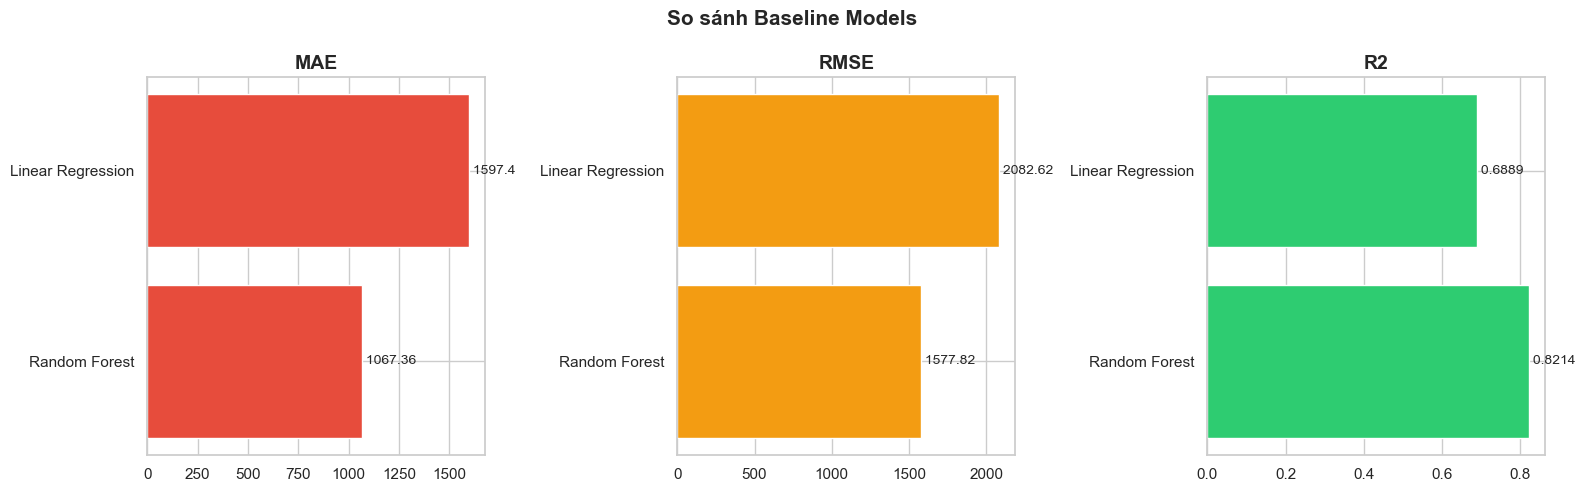

In [30]:
# Bảng so sánh
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(results_df)

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_list = ["MAE", "RMSE", "R2"]
colors = ["#e74c3c", "#f39c12", "#2ecc71"]

for ax, metric, color in zip(axes, metrics_list, colors):
    df_sorted = results_df.sort_values(metric, ascending=(metric != "R2"))
    ax.barh(df_sorted["model"], df_sorted[metric], color=color, edgecolor="white")
    ax.set_title(metric, fontsize=14, fontweight="bold")
    for i, v in enumerate(df_sorted[metric]):
        ax.text(v, i, f" {v}", va="center", fontsize=10)

plt.suptitle("So sánh Baseline Models", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

<!-- @format -->

## 6. Lưu mô hình Baseline


In [31]:
models_to_save = {
    "linear_regression": lr_pipe,
    "random_forest": rf_pipe,
}
for name, pipe in models_to_save.items():
    path = MODELS_DIR / "baseline" / f"{name}.joblib"
    save_model(pipe, path)
    print(f"Saved: {path}")

Saved: D:\Data_Mining\DataMining-FlightPricePrediction\models\baseline\linear_regression.joblib
Saved: D:\Data_Mining\DataMining-FlightPricePrediction\models\baseline\random_forest.joblib


<!-- @format -->

## 7. Tuning Random Forest (RandomizedSearchCV)

Sử dụng `RandomizedSearchCV` để tìm bộ hyperparameters tối ưu cho Random Forest:

- **n_estimators**: Số lượng cây quyết định
- **max_depth**: Độ sâu tối đa của mỗi cây
- **min_samples_split / min_samples_leaf**: Kiểm soát overfitting
- **max_features**: Số features xem xét khi tách nhánh


In [32]:
rf_tune_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [10, 15, 20, 25, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_search = RandomizedSearchCV(
    rf_tune_pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=CV_FOLDS,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

print("Đang tuning Random Forest...")
rf_search.fit(X_train, y_train)
print(f"\nBest params: {rf_search.best_params_}")
print(f"Best CV RMSE: {-rf_search.best_score_:.2f}")

# Đánh giá trên test set
rf_tuned_pipe = rf_search.best_estimator_
y_pred_tuned = rf_tuned_pipe.predict(X_test)
mae_t = mean_absolute_error(y_test, y_pred_tuned)
rmse_t = mean_squared_error(y_test, y_pred_tuned) ** 0.5
r2_t = r2_score(y_test, y_pred_tuned)

rf_tuned_metrics = {"model": "Random Forest (tuned)", "MAE": round(mae_t, 2), "RMSE": round(rmse_t, 2), "R2": round(r2_t, 4)}
print(f"\nTest set: MAE={mae_t:.2f}, RMSE={rmse_t:.2f}, R²={r2_t:.4f}")

Đang tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Best CV RMSE: 3208.95

Test set: MAE=1149.23, RMSE=1572.62, R²=0.8226


In [33]:
# Lưu tuned model
tuned_path = MODELS_DIR / "tuned" / "random_forest_tuned.joblib"
save_model(rf_tuned_pipe, tuned_path)
print(f"Saved tuned model: {tuned_path}")

Saved tuned model: D:\Data_Mining\DataMining-FlightPricePrediction\models\tuned\random_forest_tuned.joblib


<!-- @format -->

## 8. So sánh tổng hợp: Baseline vs Tuned


,model,MAE,RMSE,R2
0,Random Forest (tuned),1149.23,1572.62,0.8226
1,Random Forest,1067.36,1577.82,0.8214
2,Linear Regression,1597.40,2082.62,0.6889


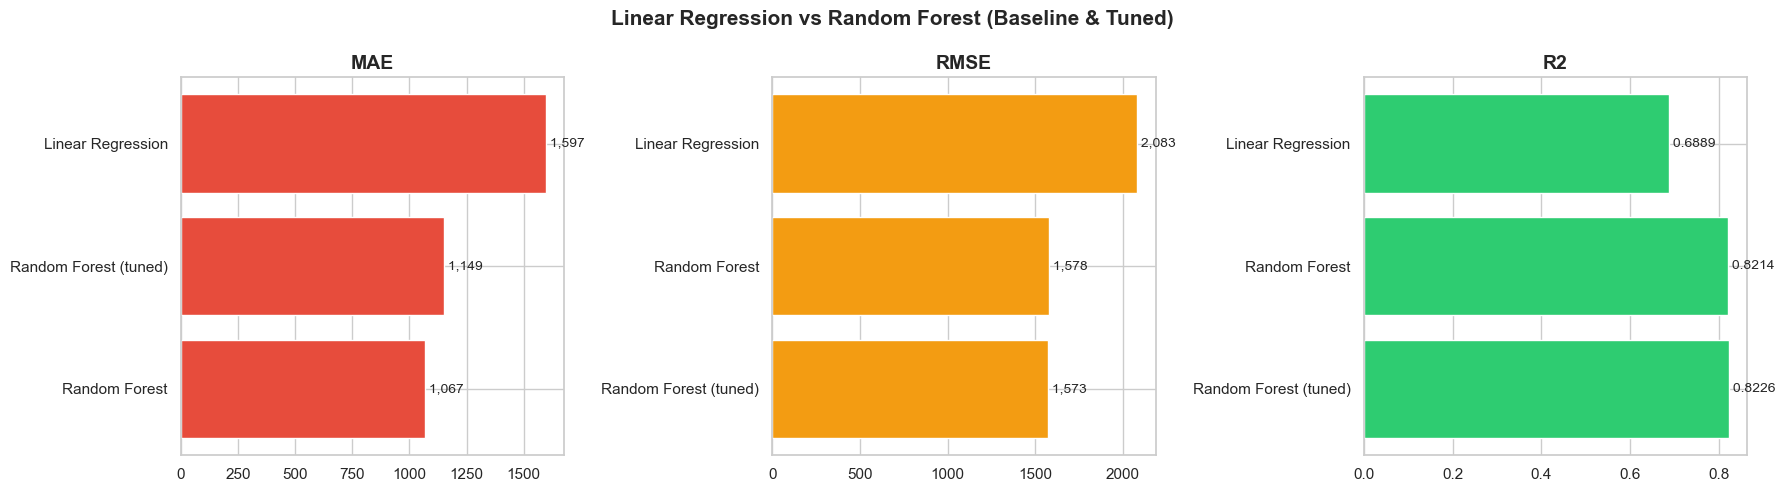

In [34]:
# Tổng hợp kết quả: LR baseline + RF baseline + RF tuned
all_results = results + [rf_tuned_metrics]
final_df = pd.DataFrame(all_results).sort_values("R2", ascending=False).reset_index(drop=True)
display(final_df)

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_list = ["MAE", "RMSE", "R2"]
colors = ["#e74c3c", "#f39c12", "#2ecc71"]

for ax, metric, color in zip(axes, metrics_list, colors):
    df_sorted = final_df.sort_values(metric, ascending=(metric != "R2"))
    bars = ax.barh(df_sorted["model"], df_sorted[metric], color=color, edgecolor="white")
    ax.set_title(metric, fontsize=14, fontweight="bold")
    for i, v in enumerate(df_sorted[metric]):
        fmt = f"{v:.4f}" if metric == "R2" else f"{v:,.0f}"
        ax.text(v, i, f" {fmt}", va="center", fontsize=10)

plt.suptitle("Linear Regression vs Random Forest (Baseline & Tuned)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

<!-- @format -->

## Nhận xét

- **Random Forest** cho kết quả vượt trội so với Linear Regression nhờ khả năng nắm bắt quan hệ **phi tuyến** giữa features và giá vé.
- **Linear Regression** hạn chế vì giả định quan hệ tuyến tính, không phù hợp với dữ liệu có tương tác phức tạp.
- **RandomizedSearchCV** giúp tìm bộ hyperparameters tối ưu cho Random Forest, cải thiện thêm hiệu suất so với baseline.

**Bước tiếp theo:** Notebook 04 sẽ thực hiện đánh giá cuối cùng với biểu đồ chi tiết (Actual vs Predicted, Residuals, Feature Importance).
